<div style="background-color:Pink; padding:10px; border-radius:5px; border:1px solid black;">
    <h1 style="color:black; text-align:center;">Predicting Pneumonia in Chest X-Ray Images</h1>
    <h3 style="color:black; text-align:center;">An exploration on the efficacy of different modeling techniques</h3>
    <h3 style="color:gray; text-align:center;">CNN Modeling</h3>
</div>

## Step 0: Import Modules

---

In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array, apply_affine_transform
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from PIL import Image
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_auc_score, roc_curve
tf.random.set_seed(42)

## Step 1: Load Dataset

---

We load the datasets containing the file paths to the cleaned and prepared images. We pick a standard 256 by 256 pixel format for the images and a standard but smaller batch size of 16.

PNEUMONIA cases are recoded to 1s as strings and NORMAL cases are recoded to 0s as strings. This is for formating in the ImageDataGenerator process.

In [3]:
# Set image dimensions
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

# Load CSV files containing cleaned image paths and labels
train_df = pd.read_csv("data/train_data_cleaned.csv")
test_df = pd.read_csv("data/test_data_cleaned.csv")
val_df = pd.read_csv("data/val_data_cleaned.csv")

# Convert labels to binary: 0 = NORMAL, 1 = PNEUMONIA
train_df['label'] = train_df['label'].map({'NORMAL': 0, 'PNEUMONIA': 1}).astype(str)
val_df['label'] = val_df['label'].map({'NORMAL': 0, 'PNEUMONIA': 1}).astype(str)
test_df['label'] = test_df['label'].map({'NORMAL': 0, 'PNEUMONIA': 1}).astype(str)

# Verify the conversion
print(train_df['label'].value_counts(normalize = True))

label
1    0.741811
0    0.258189
Name: proportion, dtype: float64


Most of our cases are labeled PNEUMONIA, however as previously discussed we can use this imbalance to our advantage to prevent more false negatives in favor of false positives. This is favorable due to the healthcare context.

### Step 1.1: Data Augmentation and Image Generator

Here we build out the ImageDataGenerator with some small data augmentation. We don't want to augment too much because we don't want to destroy the information contained in the X-rays, we simply want to add variation so the network does not completely memorize the training data.

In [5]:
# Augmentation for training images
train_datagen = ImageDataGenerator(
    rescale=1./255,               # Normalize pixel values
    rotation_range=10,            # Random rotations up to 10 degrees
    width_shift_range=0.1,        # Horizontal shift up to 10%
    height_shift_range=0.1,       # Vertical shift up to 10%
    zoom_range=0.1,               # Slight zoom in/out
    brightness_range=[0.9, 1.1],  # Adjust brightness slightly
    fill_mode='constant'
)

# Only rescaling for validation/test images
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

### Step 1.2: Custom CNN Data Generators

In [7]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    color_mode='grayscale',  # load images as grayscale
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True,
    keep_aspect_ratio=True
)

val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False,
    keep_aspect_ratio=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    color_mode='grayscale',
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False,
    keep_aspect_ratio=True
)

Found 5190 validated image filenames belonging to 2 classes.
Found 16 validated image filenames belonging to 2 classes.
Found 618 validated image filenames belonging to 2 classes.


### Step 1.3: Pretrained CNN Data Generators

In [9]:
train_generator_rgb = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    color_mode='rgb',  # load images as RGB for pretrained networks
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=True,
    keep_aspect_ratio=True
)

val_generator_rgb = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False,
    keep_aspect_ratio=True
)

test_generator_rgb = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    color_mode='rgb',
    class_mode='binary',
    batch_size=BATCH_SIZE,
    shuffle=False,
    keep_aspect_ratio=True
)

Found 5190 validated image filenames belonging to 2 classes.
Found 16 validated image filenames belonging to 2 classes.
Found 618 validated image filenames belonging to 2 classes.


### Step 1.4: Sample Augmented Images

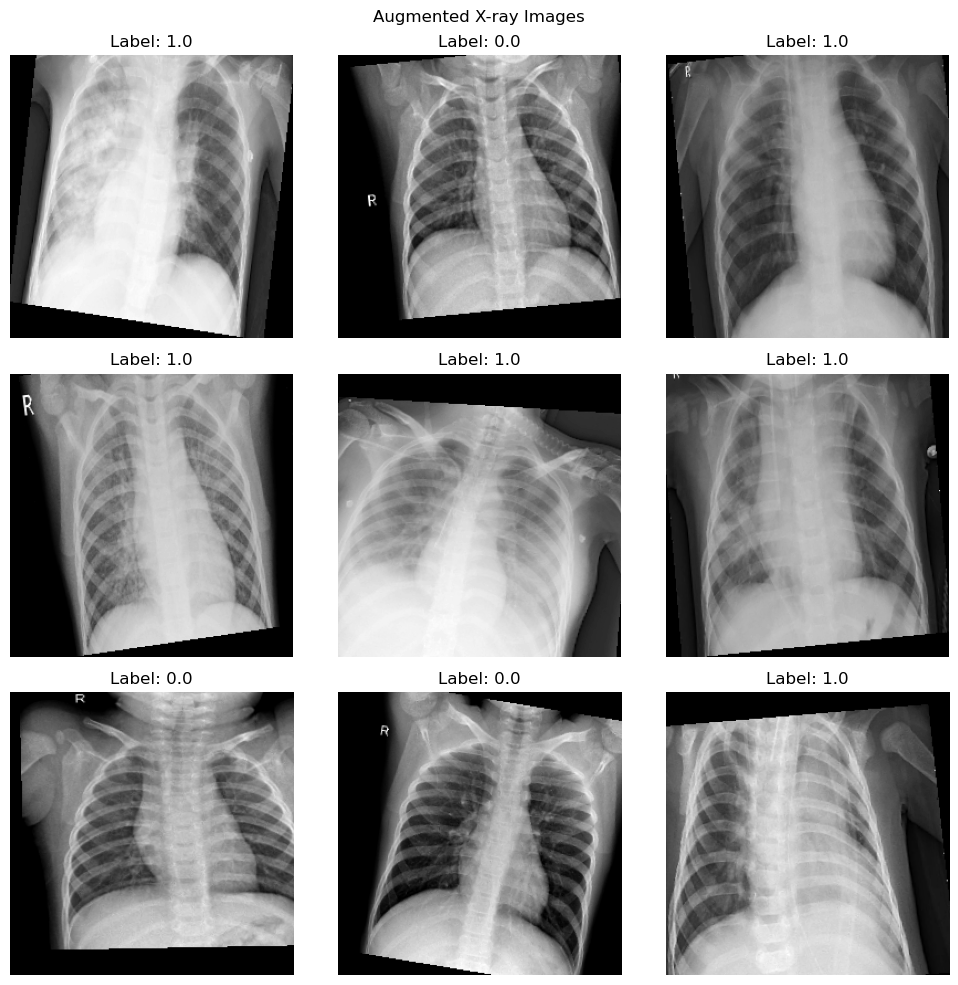

In [11]:
x_batch, y_batch = next(train_generator)  # get one batch of augmented images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_batch[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_batch[i]}")
    plt.axis("off")
plt.suptitle("Augmented X-ray Images")
plt.tight_layout()
plt.savefig("images/augmented_x_ray_images.png")
plt.show()

Now that we have uploaded the dataset containing the cleaned image paths, built a ImageDataGenerator, and data generators (train, test, and validation), we can move on to building out our first CNN.

## Step 2: Build CNN from Scratch

---

### Step 2.1: CNN Architecture

- First Convolutional Block
    - 64 filters, ReLU activation, L2 Regularization (to prevent overfitting)
    - Pooling layer
- Second Convolutional Block
    - 128 filters, ReLU activation, L2 Regulatization (to prevent overfitting)
    - Pooling Layer
- Third Convolutional Block
    - 256 filters, ReLU activation, L2 Regularization (to prevent overfitting)
    - Pooling Layer
- Flattening Layer
- Fully Connected Dense Layer
    - 256 neurons, ReLU activation, L2 Regularization (to prevent overfitting)
- Dropout
    - 50% of neurons dropped to prevent overfitting
- Output Layer
    - Single sigmoid neuron
 
This is just a simple CNN I built based off of similar architecture I found through some quick research. The regularization techniques were added as I noticed the function learning too quickly and overfitting on the training set.

Lastly, I used a dynamic learning rate that reduced everytime the testing loss did not improve for 3 iterations.

In [13]:
# Define Model with Regularization
cnn_model = Sequential([
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.build(input_shape = (train_generator.n, IMG_SIZE[0], IMG_SIZE[1], 1))

# Compile Model with Lower LR
cnn_model.compile(
    optimizer=Adam(learning_rate=0.00005),  # 🔽 Lower learning rate
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Define Callbacks
lr_reduction = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

# Train CNN using augmented dataset
cnn_model_history = cnn_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=40,
    callbacks=[lr_reduction]
)

2025-03-24 08:11:05.109563: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-03-24 08:11:05.109634: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-03-24 08:11:05.109642: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-03-24 08:11:05.109684: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-24 08:11:05.109717: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` i

Epoch 1/40


2025-03-24 08:11:05.725522: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


325/325 ━━━━━━━━━━━━━━━━━━━━ 61s 184ms/step - accuracy: 0.7281 - loss: 4.4368 - val_accuracy: 0.6262 - val_loss: 1.7286 - learning_rate: 5.0000e-05
Epoch 2/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.7769 - loss: 1.4691 - val_accuracy: 0.7621 - val_loss: 1.0945 - learning_rate: 5.0000e-05
Epoch 3/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.8389 - loss: 0.9661 - val_accuracy: 0.8689 - val_loss: 0.8052 - learning_rate: 5.0000e-05
Epoch 4/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.8732 - loss: 0.7697 - val_accuracy: 0.8414 - val_loss: 0.7613 - learning_rate: 5.0000e-05
Epoch 5/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.8721 - loss: 0.7041 - val_accuracy: 0.8722 - val_loss: 0.6695 - learning_rate: 5.0000e-05
Epoch 6/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.8929 - loss: 0.6413 - val_accuracy: 0.8285 - val_loss: 0.7144 - learning_rate: 5.0000e-05
Epoch 7/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - 

### Step 2.2: Training loss and testing loss

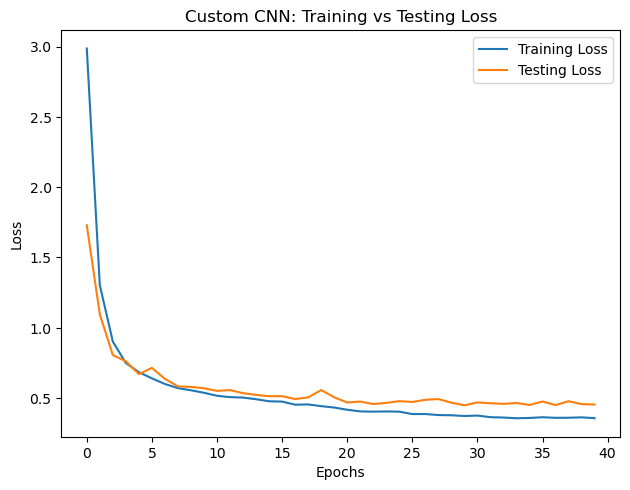

In [15]:
plt.plot(cnn_model_history.history["loss"], label="Training Loss")
plt.plot(cnn_model_history.history["val_loss"], label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/Custom_CNN_Training_vs_Testing_Loss")
plt.title("Custom CNN: Training vs Testing Loss")
plt.show()

Our model appears to have trained decently well, but it is possible towards the end of training we are overfitting. This could be due to the number of iterations used, as we can see that the loss starts to flatten after 10 epochs.

### Step 2.3: Model Evaluation

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8429 - loss: 0.5472
Test Accuracy: 0.8835
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


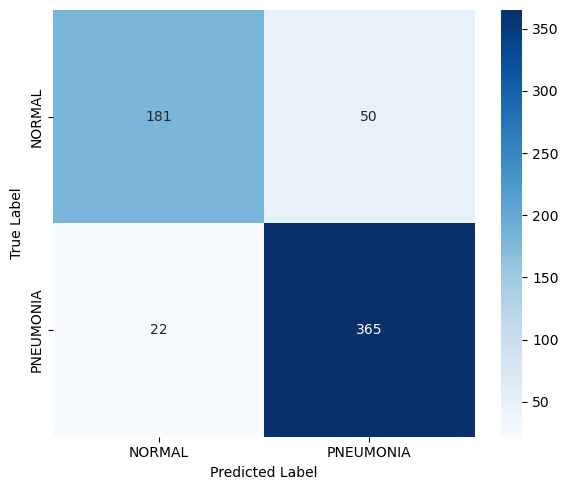

CNN Model Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83       231
           1       0.88      0.94      0.91       387

    accuracy                           0.88       618
   macro avg       0.89      0.86      0.87       618
weighted avg       0.88      0.88      0.88       618



In [17]:
# Evaluate on test set
test_loss, test_acc = cnn_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Get Predictions
y_pred_probs = cnn_model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()  # Convert to binary labels (0 or 1)

# Labels are already binary, no need for np.argmax()
y_true = test_generator.labels  # array of 0s and 1s

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"], 
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('images/CNN_Model_Classification_Report.png')
plt.show()

print("CNN Model Classification Report:\n", classification_report(y_true, y_pred))

Base CNN Accuracy, Precision, Recall, and F1-Score:

- **TP (True Positives - Pneumonia correctly identfied):** 365
- **FN (False Negatives - Pneumonia misclassified as Normal):** 22
- **TN (True Negatives - Normal correctly identified):** 181
- **FP (False Positives - Normal misclassified as Pneumonia):** 50

$\text{Accuracy} = \frac{\text{TP+TN}}{\text{TP+FP+TN+FN}}$
$ = \frac{365+181}{365+50+181+22} = \frac{546}{618} \approx 0.8835$

$\text{Recall} =  \frac{\text{TP}}{\text{TP+FN}}$
$ = \frac{365}{365+22}=\frac{365}{387} \approx 0.9432$

$\text{Precision} = \frac{\text{TP}}{\text{TP+FP}}$
$ = \frac{365}{365+50}=\frac{365}{415} \approx 0.8795$

$\text{F1-Score} = 2 \times \frac{\text{Precision}\times \text{Recall}}{\text{Precision + Recall}}$
$ = 2 \times \frac{0.8795 \times 0.9432}{0.8795+0.9432} = 2 \times \frac{0.8295}{1.8227} \approx 0.9102$

This model out performed all of the previous models in terms of precision, F1-score, and accuracy. And took just about the same amount of time to find the best random forest model that performed worse. This also did not require any feature extraction which makes it an attractive candidate for use.

## Step 3: Use Pretrained Imagenet CNN: VGG16

---

### Step 3.1: VGG16 Model Information and Architecture

The VGG16 model was built for ImageNet. The architecture is too complex to go into for now, but this is a common pretrained classification CNN. More information on this model can be found [here](https://arxiv.org/abs/1409.1556). 

We do add a few layers to the bottom that we used in the first CNN model. This again is to discourage overfitting.

In [19]:
# Load Pretrained Model (VGG16, Without Fully Connected Layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Ensure all layers in the base model are frozen initially
for layer in base_model.layers:
    layer.trainable = False

# Correctly Connect New Fully Connected Layers to the Model Graph
x = base_model.output  # Must be a tensor!
x = Flatten()(x)  # Convert to 1D
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x) 

In [21]:
# Define Pretrained Model
pretrained_model = Model(inputs=base_model.input, outputs=x)

# Compile Model
pretrained_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train Only the New Layers
pretrained_model_history = pretrained_model.fit(
    train_generator_rgb,
    validation_data=test_generator_rgb,
    epochs=40,
    callbacks=[lr_reduction]
)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 57s 174ms/step - accuracy: 0.8390 - loss: 2.7920 - val_accuracy: 0.8819 - val_loss: 0.9066 - learning_rate: 1.0000e-04
Epoch 2/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 56s 173ms/step - accuracy: 0.9315 - loss: 0.6613 - val_accuracy: 0.8916 - val_loss: 0.5963 - learning_rate: 1.0000e-04
Epoch 3/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 57s 176ms/step - accuracy: 0.9296 - loss: 0.4479 - val_accuracy: 0.9013 - val_loss: 0.4740 - learning_rate: 1.0000e-04
Epoch 4/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 57s 174ms/step - accuracy: 0.9447 - loss: 0.3181 - val_accuracy: 0.9061 - val_loss: 0.4049 - learning_rate: 1.0000e-04
Epoch 5/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 56s 173ms/step - accuracy: 0.9457 - loss: 0.2613 - val_accuracy: 0.9094 - val_loss: 0.3607 - learning_rate: 1.0000e-04
Epoch 6/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 56s 173ms/step - accuracy: 0.9503 - loss: 0.2190 - val_accuracy: 0.9159 - val_loss: 0.3123 - learning_rate: 1.0000e-04
Epoch 7/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 56s 17

### Step 3.2: Training loss and testing loss

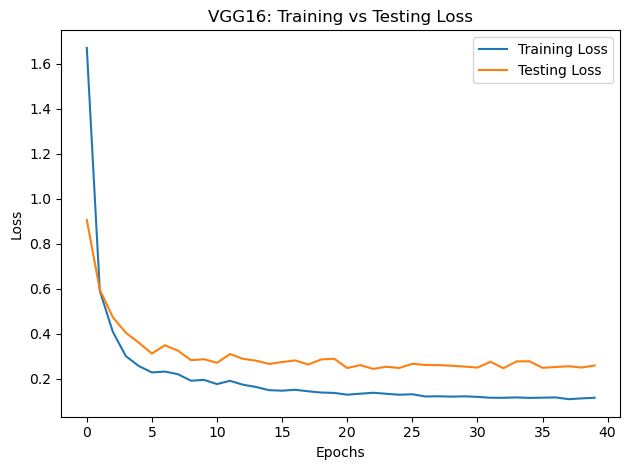

In [23]:
plt.plot(pretrained_model_history.history["loss"], label="Training Loss")
plt.plot(pretrained_model_history.history["val_loss"], label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("VGG16: Training vs Testing Loss")
plt.tight_layout()
plt.savefig("images/VGG16_Training_vs_Testing_Loss.png")
plt.show()

### Step 3.3: Fine tuning last 4 layers of VGG16

In [25]:
# Fine-Tune the Last 4 Layers of VGG16
for layer in base_model.layers[-4:]:  # Unfreeze last 4 layers
    layer.trainable = True

# Recompile with Lower Learning Rate
pretrained_model.compile(optimizer=Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])

# Train with Fine-Tuning
pretrained_model_finetuning_history = pretrained_model.fit(
    train_generator_rgb,
    validation_data=test_generator_rgb,
    epochs=40,
    callbacks=[lr_reduction]
)

Epoch 1/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 61s 185ms/step - accuracy: 0.9738 - loss: 0.1151 - val_accuracy: 0.9159 - val_loss: 0.3259 - learning_rate: 1.0000e-05
Epoch 2/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.9736 - loss: 0.0959 - val_accuracy: 0.9353 - val_loss: 0.2563 - learning_rate: 1.0000e-05
Epoch 3/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 61s 187ms/step - accuracy: 0.9784 - loss: 0.0887 - val_accuracy: 0.9159 - val_loss: 0.3295 - learning_rate: 1.0000e-05
Epoch 4/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 61s 188ms/step - accuracy: 0.9808 - loss: 0.0876 - val_accuracy: 0.9434 - val_loss: 0.2515 - learning_rate: 1.0000e-05
Epoch 5/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 185ms/step - accuracy: 0.9822 - loss: 0.0783 - val_accuracy: 0.9320 - val_loss: 0.2463 - learning_rate: 1.0000e-05
Epoch 6/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.9863 - loss: 0.0654 - val_accuracy: 0.9110 - val_loss: 0.3918 - learning_rate: 1.0000e-05
Epoch 7/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 60s 18

### Step 3.4: Fine-tuning training loss and testing loss

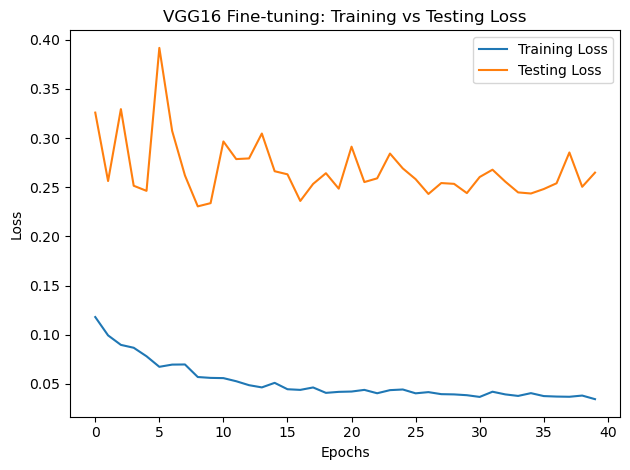

In [27]:
plt.plot(pretrained_model_finetuning_history.history["loss"], label="Training Loss")
plt.plot(pretrained_model_finetuning_history.history["val_loss"], label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("VGG16 Fine-tuning: Training vs Testing Loss")
plt.tight_layout()
plt.savefig("images/VGG16_Fine-tuning_Training_vs_Testing_Loss.png")
plt.show()

### Step 3.5: Model Evaluation

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9207 - loss: 0.4035
Test Accuracy: 0.9482
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step


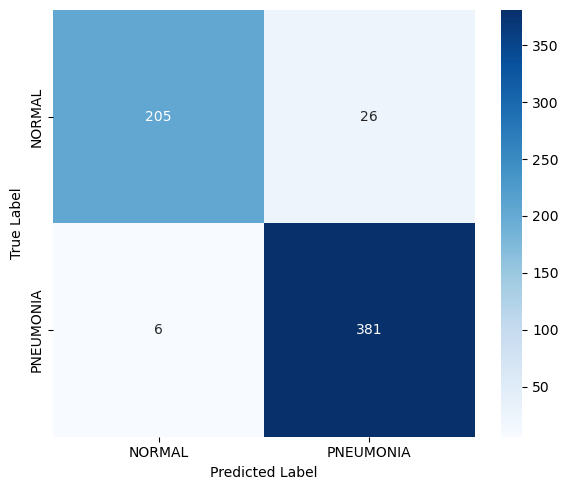

CNN Model Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       231
           1       0.94      0.98      0.96       387

    accuracy                           0.95       618
   macro avg       0.95      0.94      0.94       618
weighted avg       0.95      0.95      0.95       618



In [29]:
# Evaluate on test set
test_loss_vgg16, test_acc_vgg16 = pretrained_model.evaluate(test_generator_rgb)
print(f"Test Accuracy: {test_acc_vgg16:.4f}")

# Get Predictions
y_pred_probs_vgg16 = pretrained_model.predict(test_generator_rgb)
y_pred_vgg16 = (y_pred_probs_vgg16 > 0.5).astype(int).ravel()  # Convert to binary labels (0 or 1)

# Labels are already binary, no need for np.argmax()
y_true = test_generator_rgb.labels  # array of 0s and 1s

cm_vgg16 = confusion_matrix(y_true, y_pred_vgg16)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_vgg16, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"], 
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('images/VGG16_Model_Classification_Report.png')
plt.show()

print("CNN Model Classification Report:\n", classification_report(y_true, y_pred_vgg16))

VGG16 CNN Accuracy, Precision, Recall, and F1-Score:

- **TP (True Positives - Pneumonia correctly identfied):** 381
- **FN (False Negatives - Pneumonia misclassified as Normal):** 6
- **TN (True Negatives - Normal correctly identified):** 205
- **FP (False Positives - Normal misclassified as Pneumonia):** 26

$\text{Accuracy} = \frac{\text{TP+TN}}{\text{TP+FP+TN+FN}}$
$ = \frac{381+205}{381+26+205+6} = \frac{586}{618} \approx 0.9482$

$\text{Recall} =  \frac{\text{TP}}{\text{TP+FN}}$
$ = \frac{381}{381+6}=\frac{381}{387} \approx 0.9845$

$\text{Precision} = \frac{\text{TP}}{\text{TP+FP}}$
$ = \frac{381}{381+26}=\frac{381}{407} \approx 0.9361$

$\text{F1-Score} = 2 \times \frac{\text{Precision}\times \text{Recall}}{\text{Precision + Recall}}$
$ = 2 \times \frac{0.9361 \times 0.9845}{0.9361+0.9845} = 2 \times \frac{0.9216}{1.9206} \approx 0.9597$

## Step 4: Use Pretrained Imagenet CNN: DenseNet121

---

In [31]:
# Load Pretrained DenseNet121 (Without Fully Connected Layers)
base_model_densenet = DenseNet121(weights="imagenet", include_top=False, input_shape=(256, 256, 3))

# Freeze all layers in the base model
for layer in base_model_densenet.layers:
    layer.trainable = False

# Add Custom Fully Connected Layers
x = base_model_densenet.output
x = GlobalAveragePooling2D()(x)  # Use Global Average Pooling instead of Flatten
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x) 

# Define the new model
densenet_model = Model(inputs=base_model_densenet.input, outputs=x)

# Compile Model
densenet_model.compile(optimizer=Adam(learning_rate=0.00005), loss="binary_crossentropy", metrics=["accuracy"])

In [33]:
# Train Only the New Layers
densenet_model_history = densenet_model.fit(
    train_generator_rgb,
    validation_data=test_generator_rgb,
    epochs=40,
    callbacks=[lr_reduction]
)

Epoch 1/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 66s 188ms/step - accuracy: 0.6578 - loss: 4.3835 - val_accuracy: 0.7524 - val_loss: 3.0442 - learning_rate: 5.0000e-05
Epoch 2/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.8535 - loss: 2.6836 - val_accuracy: 0.8608 - val_loss: 2.0735 - learning_rate: 5.0000e-05
Epoch 3/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 178ms/step - accuracy: 0.8952 - loss: 1.8347 - val_accuracy: 0.8269 - val_loss: 1.6124 - learning_rate: 5.0000e-05
Epoch 4/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9149 - loss: 1.3514 - val_accuracy: 0.8511 - val_loss: 1.3059 - learning_rate: 5.0000e-05
Epoch 5/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9217 - loss: 1.0699 - val_accuracy: 0.8333 - val_loss: 1.1600 - learning_rate: 5.0000e-05
Epoch 6/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9258 - loss: 0.9080 - val_accuracy: 0.8511 - val_loss: 1.0285 - learning_rate: 5.0000e-05
Epoch 7/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 17

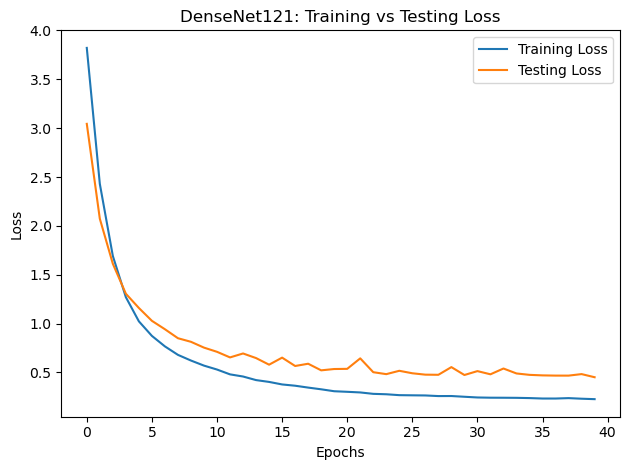

In [35]:
plt.plot(densenet_model_history.history["loss"], label="Training Loss")
plt.plot(densenet_model_history.history["val_loss"], label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("DenseNet121: Training vs Testing Loss")
plt.tight_layout()
plt.savefig("images/DenseNet121_Training_vs_Testing_Loss.png")
plt.show()

In [37]:
# Fine-Tune the Last 4 Layers of VGG16
for layer in base_model_densenet.layers[-4:]:  # Unfreeze last 4 layers
    layer.trainable = True

# Recompile with Lower Learning Rate
densenet_model.compile(optimizer=Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])

# Train with Fine-Tuning
densenet_model_finetuning_history = densenet_model.fit(
    train_generator_rgb,
    validation_data=test_generator_rgb,
    epochs=40,
    callbacks=[lr_reduction]
)

Epoch 1/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 67s 189ms/step - accuracy: 0.9361 - loss: 0.2736 - val_accuracy: 0.8819 - val_loss: 0.4077 - learning_rate: 1.0000e-05
Epoch 2/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9436 - loss: 0.2560 - val_accuracy: 0.8803 - val_loss: 0.4124 - learning_rate: 1.0000e-05
Epoch 3/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9432 - loss: 0.2526 - val_accuracy: 0.8786 - val_loss: 0.4149 - learning_rate: 1.0000e-05
Epoch 4/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9508 - loss: 0.2331 - val_accuracy: 0.8819 - val_loss: 0.4026 - learning_rate: 1.0000e-05
Epoch 5/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9531 - loss: 0.2292 - val_accuracy: 0.8819 - val_loss: 0.3975 - learning_rate: 1.0000e-05
Epoch 6/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 177ms/step - accuracy: 0.9455 - loss: 0.2425 - val_accuracy: 0.8835 - val_loss: 0.3857 - learning_rate: 1.0000e-05
Epoch 7/40
325/325 ━━━━━━━━━━━━━━━━━━━━ 58s 17

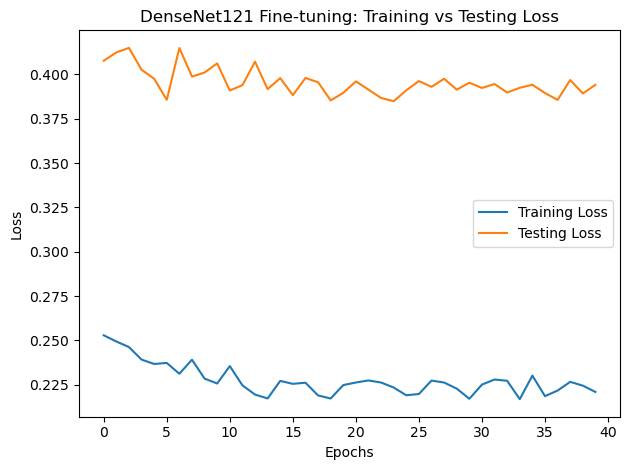

In [39]:
plt.plot(densenet_model_finetuning_history.history["loss"], label="Training Loss")
plt.plot(densenet_model_finetuning_history.history["val_loss"], label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("DenseNet121 Fine-tuning: Training vs Testing Loss")
plt.tight_layout()
plt.savefig("images/DenseNet121_Fine-tuning_Training_vs_Testing_Loss.png")
plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.8003 - loss: 0.5917
Test Accuracy: 0.8803
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step


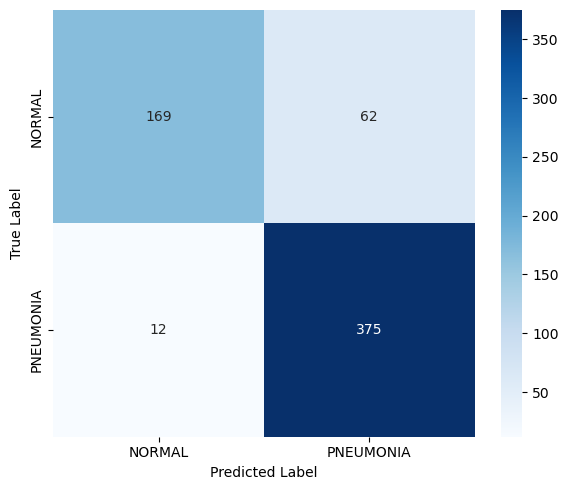

CNN Model Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.73      0.82       231
           1       0.86      0.97      0.91       387

    accuracy                           0.88       618
   macro avg       0.90      0.85      0.87       618
weighted avg       0.89      0.88      0.88       618



In [59]:
# Evaluate on test set
test_loss_densenet, test_acc_densenet = densenet_model.evaluate(test_generator_rgb)
print(f"Test Accuracy: {test_acc_densenet:.4f}")

# Get Predictions
y_pred_probs_densenet = densenet_model.predict(test_generator_rgb)
y_pred_densenet = (y_pred_probs_densenet > 0.5).astype(int).ravel()  # Convert to binary labels (0 or 1)

y_true = test_generator.labels  # array of 0s and 1s

cm_densenet = confusion_matrix(y_true, y_pred_densenet)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_densenet, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"], 
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('images/DenseNet121_Model_Classification_Report.png')
plt.show()

print("CNN Model Classification Report:\n", classification_report(y_true, y_pred_densenet))

DenseNet121 CNN Accuracy, Precision, Recall, and F1-Score:

- **TP (True Positives - Pneumonia correctly identfied):** 375
- **FN (False Negatives - Pneumonia misclassified as Normal):** 12
- **TN (True Negatives - Normal correctly identified):** 169
- **FP (False Positives - Normal misclassified as Pneumonia):** 62

$\text{Accuracy} = \frac{\text{TP+TN}}{\text{TP+FP+TN+FN}}$
$ = \frac{375+169}{375+62+169+12} = \frac{544}{618} \approx 0.8803$

$\text{Recall} =  \frac{\text{TP}}{\text{TP+FN}}$
$ = \frac{375}{375+12}=\frac{375}{387} \approx 0.9690$

$\text{Precision} = \frac{\text{TP}}{\text{TP+FP}}$
$ = \frac{375}{375+62}=\frac{375}{437} \approx 0.8581$

$\text{F1-Score} = 2 \times \frac{\text{Precision}\times \text{Recall}}{\text{Precision + Recall}}$
$ = 2 \times \frac{0.8581 \times 0.9690}{0.8581+0.9690} = 2 \times \frac{0.8315}{1.8271} \approx 0.9102$

## Step 5: Evaluate Best Model

---

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.9207 - loss: 0.4035
Test Accuracy: 0.9482
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step


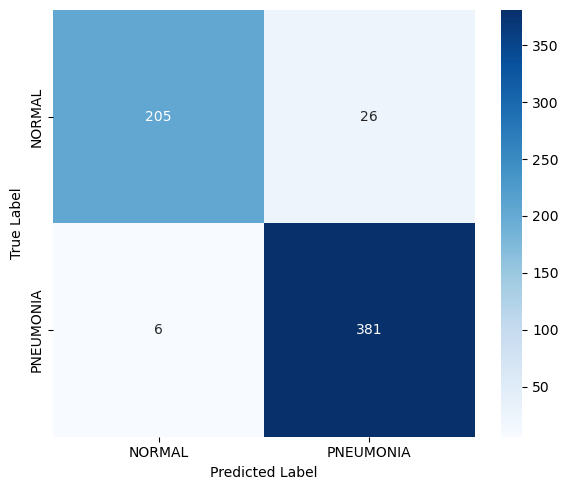

CNN Model Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       231
           1       0.94      0.98      0.96       387

    accuracy                           0.95       618
   macro avg       0.95      0.94      0.94       618
weighted avg       0.95      0.95      0.95       618



In [62]:
# Evaluate on test set
test_loss_vgg16, test_acc_vgg16 = pretrained_model.evaluate(test_generator_rgb)
print(f"Test Accuracy: {test_acc_vgg16:.4f}")

# Get Predictions
y_pred_probs_vgg16 = pretrained_model.predict(test_generator_rgb)
y_pred_vgg16 = (y_pred_probs_vgg16 > 0.5).astype(int).ravel()  # Convert to binary labels (0 or 1)

y_true = test_generator.labels  # array of 0s and 1s

cm_vgg16 = confusion_matrix(y_true, y_pred_vgg16)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_vgg16, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"], 
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('images/VGG16_Model_Classification_Report.png')
plt.show()

print("CNN Model Classification Report:\n", classification_report(y_true, y_pred_vgg16))

VGG16 CNN Accuracy, Precision, Recall, and F1-Score:

- **TP (True Positives - Pneumonia correctly identfied):** 381
- **FN (False Negatives - Pneumonia misclassified as Normal):** 6
- **TN (True Negatives - Normal correctly identified):** 205
- **FP (False Positives - Normal misclassified as Pneumonia):** 26

$\text{Accuracy} = \frac{\text{TP+TN}}{\text{TP+FP+TN+FN}}$
$ = \frac{381+205}{381+26+205+6} = \frac{586}{618} \approx 0.9482$

$\text{Recall} =  \frac{\text{TP}}{\text{TP+FN}}$
$ = \frac{381}{381+6}=\frac{381}{387} \approx 0.9845$

$\text{Precision} = \frac{\text{TP}}{\text{TP+FP}}$
$ = \frac{381}{381+26}=\frac{381}{407} \approx 0.9361$

$\text{F1-Score} = 2 \times \frac{\text{Precision}\times \text{Recall}}{\text{Precision + Recall}}$
$ = 2 \times \frac{0.9361 \times 0.9845}{0.9361+0.9845} = 2 \times \frac{0.9216}{1.9206} \approx 0.9597$

AUC-ROC: 0.936


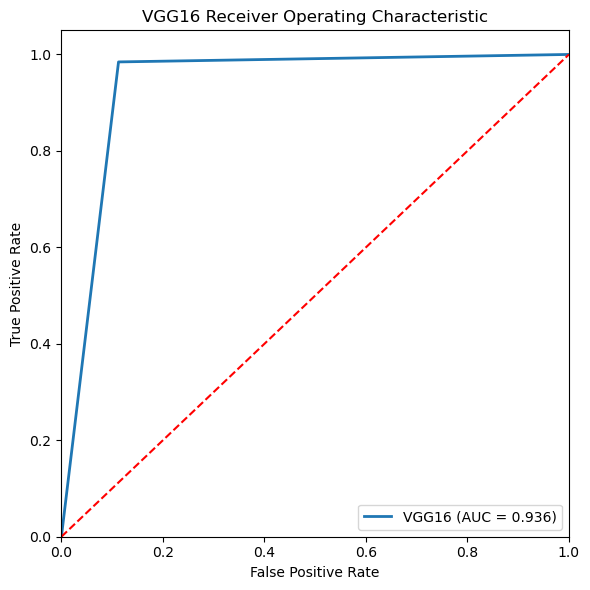

In [54]:
# Compute AUC
auc_score = roc_auc_score(y_true, y_pred_vgg16)
print(f"AUC-ROC: {auc_score:.3f}")

# Compute points for the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_vgg16)

# Plot the ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"VGG16 (AUC = {auc_score:.3f})", lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='red')  # reference line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('VGG16 Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/VGG16_ROC.png")
plt.show()

Our final model was able to achieve an exceptional AUC of 0.936

## Step 6: Validation Set

---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 1.0000 - loss: 0.0317
Validation Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


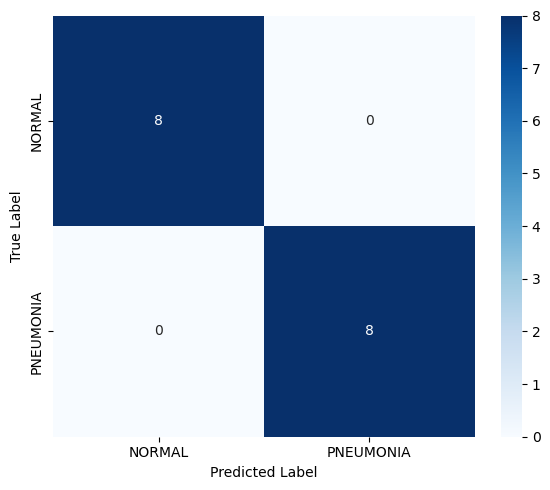

CNN Model Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [56]:
# Evaluate on test set
val_loss_vgg16, val_acc_vgg16 = pretrained_model.evaluate(val_generator_rgb)
print(f"Validation Accuracy: {val_acc_vgg16:.4f}")

# Get Predictions
y_pred_probs_vgg16_val = pretrained_model.predict(val_generator_rgb)
y_pred_vgg16_val = (y_pred_probs_vgg16_val > 0.5).astype(int).ravel()  # Convert to binary labels (0 or 1)

y_true_val = val_generator.labels  # array of 0s and 1s

cm_vgg16_val = confusion_matrix(y_true_val, y_pred_vgg16_val)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_vgg16_val, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"], 
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('images/VGG16_Model_Classification_Validation_Set_Report.png')
plt.show()

print("CNN Model Classification Report:\n", classification_report(y_true_val, y_pred_vgg16_val))

VGG16 CNN Validation Accuracy, Precision, Recall, and F1-Score:

- **TP (True Positives - Pneumonia correctly identfied):** 8
- **FN (False Negatives - Pneumonia misclassified as Normal):** 0
- **TN (True Negatives - Normal correctly identified):** 8
- **FP (False Positives - Normal misclassified as Pneumonia):** 0

$\text{Accuracy} = \frac{\text{TP+TN}}{\text{TP+FP+TN+FN}}$
$ = \frac{8+8}{8+0+8+0} = \frac{16}{16} \approx 1.0000$

$\text{Recall} =  \frac{\text{TP}}{\text{TP+FN}}$
$ = \frac{8}{8+0}=\frac{8}{8} \approx 1.0000$

$\text{Precision} = \frac{\text{TP}}{\text{TP+FP}}$
$ = \frac{8}{8+0}=\frac{8}{8} \approx 1.0000$

$\text{F1-Score} = 2 \times \frac{\text{Precision}\times \text{Recall}}{\text{Precision + Recall}}$
$ = 2 \times \frac{1.0000 \times 1.0000}{1.0000+1.0000} = 2 \times \frac{1.0000}{2.0000} \approx 1.0000$